# 3 Predictive Analytics with a) Support Vector Machines and b) Neural Networks

Following the descriptive analysis in Section 2, this section constructs two supervised models that predict taxi trip demand per spatial unit and time bucket in spatio-temporal resolution. The objective is not to forecast bucket x+1 from bucket x, but to estimate demand conditional on calendar and environmental context, for example, *"what demand can be expected on a rainy Sunday from 10-11 am around the outskirts of the city?"* Features are therefore restricted to calendar, weather, and spatial identity; the lagged demand of the immediately preceding bucket is deliberately excluded.

The canonical modeling dataset is the **H3 r6 x 4h aggregation** with cells zero-filled so that the absence of trips is represented as an observation rather than a missing row.

## Structure Rationale

The section is organised as a shared modeling foundation followed by the two model families and a comparative synthesis. Feature design and the validation strategy (3.1-3.2) are fixed first, since the resulting feature matrix, data splits, and evaluation metrics are reused by every subsequent subsection to keep results comparable. The two model families are then developed independently against this common interface. Support vector machines in 3.3-3.4 and a feedforward neural network in 3.5-3.6. Resolution sensitivity (3.7) and the holdout comparison (3.8) consume the trained models and are therefore placed last.

The feature matrix, data splits, and the evaluation metrics (MAE, RMSE, R2) are defined once in 3.1-3.2 and reused throughout, so that all reported numbers are comparable across models and resolutions.

### 3.1 Modeling dataset and feature design

The aggregated panel is reframed as a supervised regression problem with target `demand_count` and feature matrix `X = [calendar, weather, spatial identity]`. Required outputs:

- Definition of the target `demand_count` and confirmation of the zero-filled structure (every cell x bucket present).
- Calendar features derived from `timestamp`: time-of-day bucket, day-of-week, weekend indicator, month/season. Cyclical (sin/cos) encodings are applied where continuity matters (23:00 -> 00:00).
- Weather features as already present in the dataset (`temp_4h`, `rain_4h`, `snow_4h`, `precip_4h`, `wind_speed_4h`, `weather_code_4h`).
- A spatial encoding of each H3 cell. The choice between cell-centroid latitude/longitude (continuous, permitting spatial interpolation) and one-hot encoding (high cardinality) is documented and justified.
- A clean feature matrix and target reused by all downstream subsections. To avoid leakage, lagged or same-bucket demand of the target is not included.

In [24]:
import pathlib
import numpy as np
import pandas as pd

PROCESSED = pathlib.Path("../processed")

# Canonical modeling dataset from Task 1: H3 r6 x 4h, zero-filled, weather-enriched.
# One row per hexagon x 4-hour bucket. This is the base for 3.1 feature design.
df = pd.read_parquet(PROCESSED / "df_agg_r6_4h.parquet")

# --- quick look ---
print("shape:", df.shape)
print("cells:", df["location_id"].nunique(),
      "| time buckets:", df["timestamp"].nunique())
print("date range:", df["timestamp"].min(), "->", df["timestamp"].max())
print("\ncolumns / dtypes:")
print(df.dtypes)
print("\nmissing values per column:")
print(df.isna().sum())
print("\ndemand_count summary:")
print(df["demand_count"].describe())

df.head(10)

shape: (133029, 15)
cells: 27 | time buckets: 4927
date range: 2024-01-01 00:00:00 -> 2026-04-01 00:00:00

columns / dtypes:
location_id                       str
timestamp              datetime64[us]
demand_count                    int64
avg_trip_miles                Float32
avg_trip_seconds              Float64
avg_trip_total                Float32
n_unique_taxis                float64
spatial_resolution                str
temporal_resolution               str
temp_4h                       float64
rain_4h                       float64
snow_4h                       float64
precip_4h                     float64
wind_speed_4h                 float64
weather_code_4h                 int64
dtype: object

missing values per column:
location_id                0
timestamp                  0
demand_count               0
avg_trip_miles         17769
avg_trip_seconds       16845
avg_trip_total         16737
n_unique_taxis         16735
spatial_resolution         0
temporal_resolution        0
te

,location_id,timestamp,demand_count,avg_trip_miles,avg_trip_seconds,avg_trip_total,n_unique_taxis,spatial_resolution,temporal_resolution,temp_4h,rain_4h,snow_4h,precip_4h,wind_speed_4h,weather_code_4h
0,862664197ffffff,2024-01-01 00:00:00,0,<NA>,<NA>,<NA>,NaN,h3_r6,time_4h,32.950,0.0,0.112,0.016,18.450,71
1,862664197ffffff,2024-01-01 04:00:00,1,5.45,4523.0,35.75,1.0,h3_r6,time_4h,31.450,0.0,0.000,0.000,14.775,3
2,862664197ffffff,2024-01-01 08:00:00,4,8.17,6327.5,31.8375,4.0,h3_r6,time_4h,30.000,0.0,0.000,0.000,10.850,3
3,862664197ffffff,2024-01-01 12:00:00,3,4.566667,1568.0,37.456665,3.0,h3_r6,time_4h,33.625,0.0,0.000,0.000,8.450,2
4,862664197ffffff,2024-01-01 16:00:00,3,9.116667,3856.666667,25.833334,3.0,h3_r6,time_4h,30.950,0.0,0.000,0.000,8.025,0
5,862664197ffffff,2024-01-01 20:00:00,4,16.096666,647.0,36.307499,4.0,h3_r6,time_4h,28.200,0.0,0.000,0.000,10.000,3
6,862664197ffffff,2024-01-02 00:00:00,1,13.53,115.0,35.0,1.0,h3_r6,time_4h,25.050,0.0,0.000,0.000,11.050,1
7,862664197ffffff,2024-01-02 04:00:00,5,9.570001,2656.6,38.734001,5.0,h3_r6,time_4h,23.775,0.0,0.000,0.000,10.575,0
8,862664197ffffff,2024-01-02 08:00:00,4,11.6075,2471.5,39.852501,4.0,h3_r6,time_4h,26.675,0.0,0.000,0.000,13.425,3
9,862664197ffffff,2024-01-02 12:00:00,9,8.504444,2330.222222,34.876667,8.0,h3_r6,time_4h,35.250,0.0,0.000,0.000,16.300,3


In [25]:
LEAKAGE_COLS    = ["avg_trip_miles", "avg_trip_seconds", "avg_trip_total", "n_unique_taxis"]
IDENTIFIER_COLS = ["spatial_resolution", "temporal_resolution"]
WEATHER_COLS    = ["temp_4h", "rain_4h", "snow_4h", "precip_4h", "wind_speed_4h", "weather_code_4h"]

CHICAGO_CENTER = (41.8781, -87.6298)   # only used to *label* anchors, not as a feature value


def _cyclical(values, period):
    """Encode a periodic integer (hour, dow, month) as a (sin, cos) pair."""
    radians = 2 * np.pi * values / period
    return np.sin(radians), np.cos(radians)


def _h3_centroids(cell_ids):
    """Map each h3 cell id to its centre (lat, lon). Computed once per unique cell."""
    try:
        from h3 import cell_to_latlng as to_geo      # h3 v4
    except ImportError:
        from h3 import h3_to_geo as to_geo            # h3 v3
    coords = {c: to_geo(c) for c in pd.unique(cell_ids)}
    lat = cell_ids.map(lambda c: coords[c][0]).astype("float64")
    lon = cell_ids.map(lambda c: coords[c][1]).astype("float64")
    return lat, lon


def _haversine_km(lat1, lon1, lat2, lon2):
    r = 3959.0      # radius of Earth in miles is 3959.0, 6371.0 for km
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dlmb = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


def detect_hotspot_anchors(train_panel, centroid_fn=_h3_centroids, n_candidates=8):
    """
    Identify the three demand hotspots from TRAINING data only.
    Greedy farthest-point pick among the busiest cells -> three spatially
    separated anchors, then labelled by geography (core / north / south).
    Returns {name: location_id}.  Call this in 3.2 on the train split.
    """
    tot  = train_panel.groupby("location_id")["demand_count"].sum().sort_values(ascending=False)
    cand = list(tot.index[:n_candidates])
    lat, lon = centroid_fn(pd.Series(cand))
    cent = {c: (la, lo) for c, la, lo in zip(cand, lat, lon)}

    chosen = [cand[0]]                                    # busiest cell
    while len(chosen) < 3:                                # add the two most separated
        nxt = max(
            (c for c in cand if c not in chosen),
            key=lambda c: min(_haversine_km(*cent[c], *cent[s]) for s in chosen),
        )
        chosen.append(nxt)

    # label without external coords: closest-to-core = loop; of the rest, north=ohare, south=midway
    loop = min(chosen, key=lambda c: _haversine_km(*cent[c], *CHICAGO_CENTER))
    rest = sorted([c for c in chosen if c != loop], key=lambda c: cent[c][0], reverse=True)
    return {"loop": loop, "ohare": rest[0], "midway": rest[1]}


def build_features(panel, anchors, centroid_fn=_h3_centroids):
    """
    Turn an aggregated demand panel into (X, y, feature_names).

    Deterministic transforms (calendar, centroids, distances) are safe on any
    rows. `anchors` ({name: location_id}) is fitted on TRAIN in 3.2 and passed
    in, so no train/test leakage enters the feature definition.
    Resolution-agnostic: swap `centroid_fn` for census-tract centroids in 3.7.
    """
    d = panel.copy()
    y = d["demand_count"].astype("float64")

    ts = d["timestamp"]
    feats = {}
    feats["hour_sin"],  feats["hour_cos"]  = _cyclical(ts.dt.hour,     24)
    feats["dow_sin"],   feats["dow_cos"]   = _cyclical(ts.dt.dayofweek, 7)
    feats["month_sin"], feats["month_cos"] = _cyclical(ts.dt.month - 1, 12)
    feats["is_weekend"] = (ts.dt.dayofweek >= 5).astype("int64")

    lat, lon = centroid_fn(d["location_id"])
    feats["cell_lat"], feats["cell_lon"] = lat, lon
    for name, cell in anchors.items():                   # distance to each hotspot
        a_lat, a_lon = centroid_fn(pd.Series([cell]))
        feats[f"dist_to_{name}_mi"] = _haversine_km(lat, lon, a_lat.iloc[0], a_lon.iloc[0])

    X = pd.DataFrame(feats, index=d.index)
    X = pd.concat([X, d[WEATHER_COLS].astype("float64")], axis=1)
    return X, y, list(X.columns)


# --- PREVIEW ONLY (anchors on full data) so you can inspect the feature table now. ---
# In 3.2 the real call is: anchors = detect_hotspot_anchors(train_panel); build_features(split, anchors)
anchors_preview = detect_hotspot_anchors(df)
print("hotspot anchors (preview, full data):", anchors_preview)

X, y, feature_names = build_features(df, anchors_preview)
print("X shape:", X.shape, "| features:", feature_names)
print("any NaN in X?", bool(X.isna().any().any()), "| any NaN in y?", bool(y.isna().any()))
X.head()

hotspot anchors (preview, full data): {'loop': '862664c1fffffff', 'ohare': '862759347ffffff', 'midway': '862664527ffffff'}
X shape: (133029, 18) | features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'cell_lat', 'cell_lon', 'dist_to_loop_mi', 'dist_to_ohare_mi', 'dist_to_midway_mi', 'temp_4h', 'rain_4h', 'snow_4h', 'precip_4h', 'wind_speed_4h', 'weather_code_4h']
any NaN in X? False | any NaN in y? False


,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_weekend,cell_lat,cell_lon,dist_to_loop_mi,dist_to_ohare_mi,dist_to_midway_mi,temp_4h,rain_4h,snow_4h,precip_4h,wind_speed_4h,weather_code_4h
0,0.000000e+00,1.0,0.0,1.0,0.0,1.0,0,41.6769,-87.553037,14.247924,29.316515,14.26634,32.950,0.0,0.112,0.016,18.450,71.0
1,8.660254e-01,0.5,0.0,1.0,0.0,1.0,0,41.6769,-87.553037,14.247924,29.316515,14.26634,31.450,0.0,0.000,0.000,14.775,3.0
2,8.660254e-01,-0.5,0.0,1.0,0.0,1.0,0,41.6769,-87.553037,14.247924,29.316515,14.26634,30.000,0.0,0.000,0.000,10.850,3.0
3,1.224647e-16,-1.0,0.0,1.0,0.0,1.0,0,41.6769,-87.553037,14.247924,29.316515,14.26634,33.625,0.0,0.000,0.000,8.450,2.0
4,-8.660254e-01,-0.5,0.0,1.0,0.0,1.0,0,41.6769,-87.553037,14.247924,29.316515,14.26634,30.950,0.0,0.000,0.000,8.025,0.0


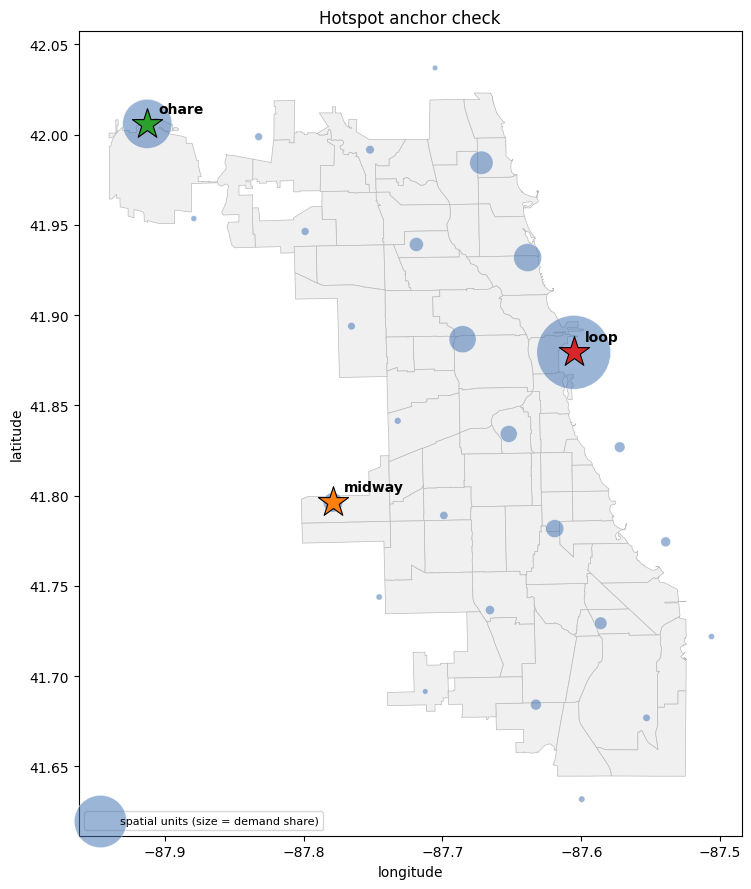

In [26]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPoly
from matplotlib.collections import PatchCollection

def plot_hotspot_check(panel, anchors, centroid_fn=_h3_centroids,
                       geojson_path="../data/chicago_community_areas.geojson"):
    """Sanity-check map: city boundaries + all spatial units sized by demand
    share, with the detected hotspot anchors starred. Works at any resolution
    as long as centroid_fn matches the panel's spatial id type."""
    tot = panel.groupby("location_id")["demand_count"].sum()
    lat, lon = centroid_fn(tot.index.to_series())
    share = tot.values / tot.values.sum() * 100

    fig, ax = plt.subplots(figsize=(8, 9))

    # boundaries for context
    gj = json.load(open(geojson_path))
    patches = []
    for f in gj["features"]:
        g = f["geometry"]
        polys = g["coordinates"] if g["type"] == "MultiPolygon" else [g["coordinates"]]
        for poly in polys:
            patches.append(MplPoly(np.array(poly[0]), closed=True))
    ax.add_collection(PatchCollection(patches, facecolor="#f0f0f0",
                      edgecolor="#bbbbbb", linewidths=0.5, zorder=0))

    ax.scatter(lon, lat, s=share * 60 + 15, c="#4a78b5", alpha=0.55,
               edgecolor="white", linewidth=0.5, zorder=2,
               label="spatial units (size = demand share)")

    colors = {"loop": "#d62728", "ohare": "#2ca02c", "midway": "#ff7f0e"}
    for name, loc in anchors.items():
        a_lat, a_lon = centroid_fn(pd.Series([loc]))
        ax.scatter(a_lon, a_lat, marker="*", s=520, c=colors.get(name, "#555"),
                   edgecolor="black", linewidth=0.8, zorder=4)
        ax.annotate(name, (a_lon.iloc[0], a_lat.iloc[0]), xytext=(8, 8),
                    textcoords="offset points", fontsize=10, fontweight="bold", zorder=5)

    ax.set(xlabel="longitude", ylabel="latitude", title="Hotspot anchor check")
    ax.set_aspect(1.3); ax.legend(loc="lower left", fontsize=8)
    plt.tight_layout(); plt.show()

plot_hotspot_check(df, anchors_preview)

#### Design decisions and justification

**Target.** The prediction target is `demand_count`, the number of trips originating in a spatial unit during a time bucket. The panel is zero-filled, so the absence of trips is represented as an observation of zero rather than a missing row; this is required for the model to learn low-demand conditions rather than only observed trips.

**Calendar encoding.** Hour-of-day, day-of-week, and month are periodic quantities, so each is encoded as a sine/cosine pair rather than a raw integer. This preserves continuity across the period boundary (23:00 is adjacent to 00:00, December to January), which an ordinal encoding would misrepresent as maximally distant. A binary weekend indicator is added because demand shifts between commuting and leisure regimes that are not fully captured by the day-of-week cycle alone.

**Spatial encoding.** Each spatial unit is represented by its centroid latitude and longitude rather than by a one-hot indicator per cell. Continuous coordinates encode relative position and distance, allowing the support vector machine and neural network to share information between neighbouring units and to generalise across space — which directly supports location-conditioned queries such as demand "around the outskirts". One-hot encoding would treat every unit as an unordered, independent category, add one column per cell, and prevent any spatial generalisation; it scales poorly with the number of features and degrades further at finer resolution. The centroid is derived deterministically from the H3 cell identifier, so reframing the retained spatial label as coordinates introduces no information loss.

**Hotspot distances.** Section 2 identified three dominant demand centres, the downtown core, and O'Hare and Midway airports. The Euclidean distance from each unit to these three anchors is added as an explicit feature. These distances are deterministic transforms of the centroid coordinates and therefore add no new information in principle, but they supply a coordinate frame aligned with the observed demand structure, which finite-sample SVM and neural-network models exploit more readily than raw coordinates. Three additional columns is a negligible dimensional cost. The anchors are identified from training data only and are not hard-coded, so the procedure transfers to other spatial resolutions (see 3.7). Distances are expressed in miles for consistency with the trip-level distance fields.

**Weather data.** The weather features are carried over exactly as aggregated in Section 1 with any redundancy (precipitation overlapping rain and snow) and the encoding of the categorical weather code left to the model stage.

**Leakage control.** The per-bucket trip aggregates (`avg_trip_miles`, `avg_trip_seconds`, `avg_trip_total`, `n_unique_taxis`) are excluded from the feature matrix: they are computed from the same trips that define the target and are therefore unavailable at prediction time. Consistent with the task framing, no lagged or same-bucket demand of the target enters the features; prediction is conditioned only on calendar, weather, and spatial position. The constant metadata columns (`spatial_resolution`, `temporal_resolution`) are also dropped. 

**Output.** The result is a feature matrix `X`, target `y`, and a `feature_names` list reused unchanged by the validation harness (3.2) and both model families (3.3–3.6), ensuring that all reported metrics are comparable.

| Feature | Group | Type | Meaning |
|---|---|---|---|
| `demand_count` | target | int | trips originating in a cell × 4h bucket (prediction target) |
| `hour_sin` / `hour_cos` | calendar | float | time-of-day (4h buckets), cyclical encoding |
| `dow_sin` / `dow_cos` | calendar | float | day-of-week, cyclical encoding |
| `month_sin` / `month_cos` | calendar | float | month/season, cyclical encoding |
| `is_weekend` | calendar | int (0/1) | weekend flag |
| `cell_lat` | spatial | float | cell centroid latitude |
| `cell_lon` | spatial | float | cell centroid longitude |
| `dist_to_loop_mi` | spatial | float | miles to downtown core |
| `dist_to_ohare_mi` | spatial | float | miles to O'Hare |
| `dist_to_midway_mi` | spatial | float | miles to Midway |
| `temp_4h` | weather | float | avg temperature (°F) |
| `rain_4h` | weather | float | total rainfall accumulated |
| `snow_4h` | weather | float | total snowfall accumulated |
| `precip_4h` | weather | float | total precipitation accumulated |
| `wind_speed_4h` | weather | float | avg wind speed |
| `weather_code_4h` | weather | int (categorical) | max weather condition code |

### 3.2 Validation strategy

A single validation procedure is defined and reused across both model families to ensure comparability. Required outputs:

- Justification of the split. Because the prediction target is demand under a given condition, a time-based holdout (training on earlier months, testing on the most recent block) most closely reflects deployment and limits leakage of near-duplicate buckets across sets. A random split may additionally be reported for contrast.
- An explicit statement of how the spatial dimension is treated: all cells appear in both training and test sets, since prediction is for known cells under unseen conditions.
- A fixed train/validation/test partition and a common metric set (MAE, RMSE, R2) used by every later subsection.
- Hyperparameter search (3.4) and network tuning (3.6) draw only on the training and validation folds; the holdout is reserved for final reporting.

#### Validation strategy

Because the target is demand conditioned on calendar, weather, and location — not on past demand — this is a supervised regression problem rather than a forecasting one. The validation design therefore uses cross-validation for full seasonal coverage, with one adjustment for the non-independence of observations.

**Grouping by day.** The 4-hour buckets of a given day and cell share weather, calendar values, and unobserved local shocks. A purely random split could place some of a day's buckets in training and the rest in test, letting the model exploit day-specific signal absent from the features and inflating the score. All splits are therefore **grouped by calendar day**: a day appears entirely in one partition or the other, never both.

**Final holdout.** A grouped random sample of whole days (15%) is set aside as an untouched test set, used only for the SVM-vs-NN comparison in 3.8. Drawing days across the full sample keeps every season represented in the holdout, which a single trailing time-block would not.

**Cross-validation.** Model selection uses `GroupKFold` (5 folds, group = day) over the development set. Hyperparameter search (3.4) and network tuning (3.6) operate only within these folds; the holdout is never touched during tuning.

**Fit-on-train-only.** The two data-derived steps from 3.1 — the hotspot anchors and feature standardisation — are fitted on training data only. Standardisation and the target transform are wrapped in a pipeline so they are refit inside each CV fold automatically.

**Target transform.** Demand is heavily right-skewed with 12.6% zeros, so it is modelled on a `log1p` scale and predictions are inverted (`expm1`) before scoring.

**Metrics.** A shared `evaluate()` reports MAE, RMSE, and R² on the original demand scale (trips per cell per 4-hour bucket), with negative predictions clipped to zero. All downstream subsections reuse this single function so results are comparable.

In [27]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE  = 42
TEST_FRACTION = 0.15      # share of DAYS held out for the final comparison
N_CV_SPLITS   = 5

# --- 1. group key: one group per calendar day (keeps a day's buckets together) ---
df = df.copy()
df["day"] = df["timestamp"].dt.floor("D")

# --- 2. final holdout: whole days, drawn across the full sample (all seasons) ---
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_FRACTION, random_state=RANDOM_STATE)
dev_idx, test_idx = next(gss.split(df, groups=df["day"]))
dev_panel  = df.iloc[dev_idx].copy()      # training + cross-validation (model selection)
test_panel = df.iloc[test_idx].copy()     # untouched until 3.8
assert set(dev_panel["day"]).isdisjoint(set(test_panel["day"]))   # no day shared

# --- 3. hotspot anchors: fit on DEV (train) only, never on the holdout ---
anchors = detect_hotspot_anchors(dev_panel)
print("anchors (fit on dev/train):", anchors)

# --- 4. build features for each partition with the SAME anchors ---
X_dev,  y_dev,  feature_names = build_features(dev_panel,  anchors)
X_test, y_test, _             = build_features(test_panel, anchors)

# group vector + splitter for cross-validation over the dev set
groups_dev = dev_panel["day"].values
cv = GroupKFold(n_splits=N_CV_SPLITS)     # use as: cv.split(X_dev, y_dev, groups_dev)

# --- 5. shared estimator wrapper: standardise features + log1p target,
#        both refit inside each CV fold; predictions returned on demand scale ---
def make_estimator(model):
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

# --- 6. shared metric set (original demand scale) ---
def evaluate(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)     # demand cannot be negative
    return {"MAE":  mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2":   r2_score(y_true, y_pred)}

print(f"dev:  {len(X_dev):>7d} rows | {dev_panel['day'].nunique()} days")
print(f"test: {len(X_test):>7d} rows | {test_panel['day'].nunique()} days "
      f"| months covered: {sorted(test_panel['timestamp'].dt.month.unique())}")
print("CV: GroupKFold, 5 folds, group = calendar day")

anchors (fit on dev/train): {'loop': '862664c1fffffff', 'ohare': '862759347ffffff', 'midway': '862664527ffffff'}
dev:   112941 rows | 698 days
test:   20088 rows | 124 days | months covered: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
CV: GroupKFold, 5 folds, group = calendar day


### 3.3 SVM - linear baseline (no kernel)

Following the assignment, the SVM is first specified without a kernel. Required outputs:

- Feature standardisation (SVMs are scale-sensitive), with the scaler fitted on the training partition only.
- A linear SVM regressor trained on the training split defined in 3.2.
- MAE, RMSE, and R2 on the holdout using the common metric set.
- A brief interpretation of which features carry weight and of the practical meaning of the error (e.g. average deviation in trips per cell per 4h bucket).

In [28]:
# This takes long to run, so just load the finished model from /models 
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVR

svm_linear_base = make_estimator(
    LinearSVR(
        max_iter=20_000,
        random_state=RANDOM_STATE
    )
)

param_grid = {
    "regressor__model__C": [0.1, 1.0, 10.0],
    "regressor__model__epsilon": [0.0, 0.05, 0.1, 0.2]
}

svm_linear_search = GridSearchCV(
    estimator=svm_linear_base,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1
)

svm_linear_search.fit(X_dev, y_dev)

svm_linear_search.best_params_, -svm_linear_search.best_score_

({'regressor__model__C': 0.1, 'regressor__model__epsilon': 0.2},
 np.float64(74.30283021167075))

In [29]:
# show some error metrics of th ebest model
svm_linear = svm_linear_search.best_estimator_

y_pred_svm_linear = svm_linear.predict(X_test)
y_pred_svm_linear = np.clip(y_pred_svm_linear, 0, None)

svm_linear_metrics = evaluate(y_test, y_pred_svm_linear)
svm_linear_metrics

{'MAE': 65.56306661279933,
 'RMSE': np.float64(203.48604708792865),
 'R2': 0.6330329831963453}

The linear SVM baseline achieves an MAE of 65.56 and an R² of 0.633 on the holdout set. This indicates that the model captures relevant spatial, temporal and weather-related demand patterns, but the high RMSE shows that large demand peaks are still difficult to predict. This is expected because the current model is purely linear and cannot capture stronger non-linear interactions between location, time and weather. Therefore, kernel-based SVMs are considered next.

In [30]:
svm_linear_results = pd.DataFrame({
    "actual": y_test,
    "predicted": np.clip(y_pred_svm_linear, 0, None)
})

svm_linear_results.head()

,actual,predicted
30,0.0,0.478728
31,4.0,1.494382
32,2.0,5.052534
33,8.0,7.746118
34,4.0,4.216091


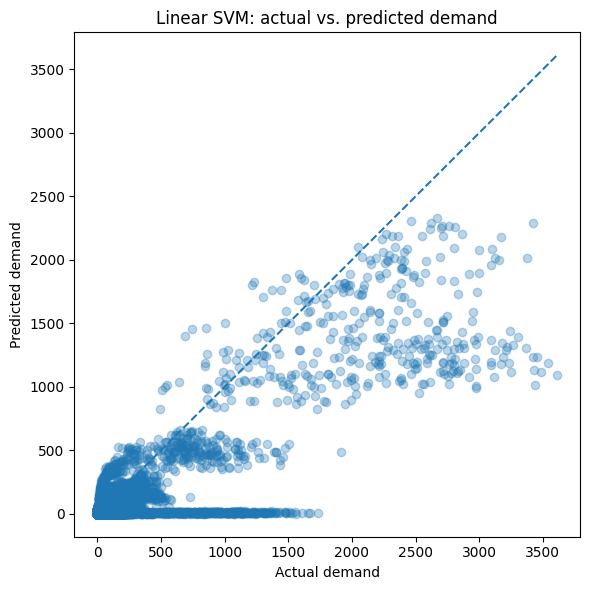

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(
    svm_linear_results["actual"],
    svm_linear_results["predicted"],
    alpha=0.3
)
plt.plot(
    [svm_linear_results["actual"].min(), svm_linear_results["actual"].max()],
    [svm_linear_results["actual"].min(), svm_linear_results["actual"].max()],
    linestyle="--"
)
plt.xlabel("Actual demand")
plt.ylabel("Predicted demand")
plt.title("Linear SVM: actual vs. predicted demand")
plt.tight_layout()
plt.show()

In [32]:
# save the model to not run the gridsearch again
import joblib

joblib.dump(svm_linear_search.best_estimator_, "../models/svm_linear_best.pkl")

# load the model (if you need to)
#svm_linear = joblib.load("../models/svm_linear_best.pkl")

['../models/svm_linear_best.pkl']

### 3.4 SVM - kernels and grid search

Model complexity is increased through non-linear kernels with tuned hyperparameters. Required outputs:

- RBF and, optionally, polynomial kernels.
- A grid search over the relevant hyperparameters (`C`, `gamma`, `epsilon`) on the training and validation folds only. As SVR scales poorly with sample size, a justified subsample or representative training slice may be used.
- Best hyperparameters and holdout performance reported against the linear baseline.
- An evaluation of model quality and a discussion of its shortfalls.

In [33]:
rng = np.random.default_rng(RANDOM_STATE)

unique_days = np.unique(groups_dev)
tune_days = rng.choice(unique_days, size=min(120, len(unique_days)), replace=False)

tune_mask = np.isin(groups_dev, tune_days)

X_tune = X_dev[tune_mask]
y_tune = y_dev[tune_mask]
groups_tune = groups_dev[tune_mask]

print(f"tuning sample: {len(X_tune)} rows | {len(tune_days)} days")
print(f"final fit: {len(X_dev)} rows | {len(unique_days)} days")

tuning sample: 19440 rows | 120 days
final fit: 112941 rows | 698 days


In [34]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, GroupKFold

svm_rbf_base = make_estimator(
    SVR(
        kernel="rbf",
        cache_size=1000
    )
)

rbf_param_grid = {
    "regressor__model__C": [1.0, 10.0, 100.0],
    "regressor__model__gamma": ["scale", 0.01, 0.1],
    "regressor__model__epsilon": [0.1, 0.2]
}

svm_rbf_search = GridSearchCV(
    estimator=svm_rbf_base,
    param_grid=rbf_param_grid,
    scoring="neg_mean_absolute_error",
    cv=GroupKFold(n_splits=3),
    n_jobs=-1,
    verbose=1
)

svm_rbf_search.fit(X_tune, y_tune, groups=groups_tune)

svm_rbf_search.best_params_, -svm_rbf_search.best_score_

Fitting 3 folds for each of 18 candidates, totalling 54 fits


({'regressor__model__C': 10.0,
  'regressor__model__epsilon': 0.1,
  'regressor__model__gamma': 0.1},
 np.float64(34.042095714259965))

In [ ]:
# i tried to refit the best model on the full dev set, but it takes very long, 
# so just use the best estimator from the search
# svm_rbf = make_estimator(
#     SVR(
#         kernel="rbf",
#         C=svm_rbf_search.best_params_["regressor__model__C"],
#         gamma=svm_rbf_search.best_params_["regressor__model__gamma"],
#         epsilon=svm_rbf_search.best_params_["regressor__model__epsilon"],
#         cache_size=1000
#     )
# )

# svm_rbf.fit(X_dev, y_dev)
svm_rbf = svm_rbf_search.best_estimator_

In [36]:
y_pred_svm_rbf = svm_rbf.predict(X_test)
y_pred_svm_rbf = np.clip(y_pred_svm_rbf, 0, None)

svm_rbf_metrics = evaluate(y_test, y_pred_svm_rbf)
svm_rbf_metrics

{'MAE': 30.83155393425266,
 'RMSE': np.float64(118.85450812169967),
 'R2': 0.8748043962303}

In [37]:
svm_comparison = pd.DataFrame([
    {"model": "Linear SVM", **svm_linear_metrics},
    {"model": "RBF SVM", **svm_rbf_metrics}
])

svm_comparison

,model,MAE,RMSE,R2
0,Linear SVM,65.563067,203.486047,0.633033
1,RBF SVM,30.831554,118.854508,0.874804


The RBF SVM clearly outperforms the linear SVM on the holdout set. MAE decreases from 65.56 to 30.83 trips per spatial-time bucket, which means the average absolute prediction error is reduced by more than half. RMSE also drops substantially from 203.49 to 118.85, showing that the RBF model handles larger demand errors and peak-demand situations better than the linear baseline.

The R² increases from 0.633 to 0.875, meaning that the RBF SVM explains a much larger share of the variation in taxi demand. This confirms that demand is not purely linear in the available features. Non-linear interactions between location, time of day, weekday patterns and weather appear to be important for predicting taxi demand.

However, the better predictive performance comes at a computational cost. The RBF SVM was much slower to train than the linear SVM and could not be efficiently refitted on the full development set. Therefore, the RBF model is a stronger non-linear benchmark, but its scalability is more limited than the linear model.

In [ ]:
joblib.dump(svm_rbf, "../models/svm_rbf_best.pkl")

# load the model (if you need to)
#svm_rbf = joblib.load("../models/svm_rbf_best.pkl")

['../models/svm_rbf_best.pkl']

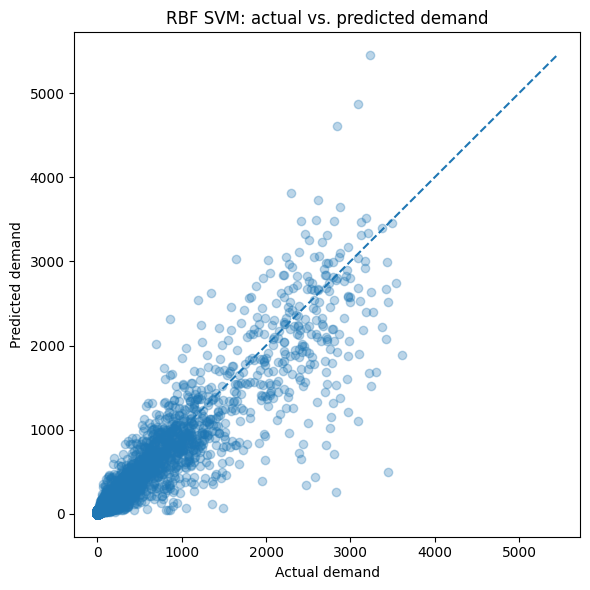

In [41]:
svm_rbf_results = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred_svm_rbf
})

plt.figure(figsize=(6, 6))
plt.scatter(
    svm_rbf_results["actual"],
    svm_rbf_results["predicted"],
    alpha=0.3
)

max_val = max(
    svm_rbf_results["actual"].max(),
    svm_rbf_results["predicted"].max()
)

plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.xlabel("Actual demand")
plt.ylabel("Predicted demand")
plt.title("RBF SVM: actual vs. predicted demand")
plt.tight_layout()
plt.show()

### 3.5 Neural network - feedforward baseline

The procedure of the SVM subsections is repeated with a feedforward neural network. Required outputs:

- Reuse of the same feature matrix, splits, scaling, and metrics from 3.1-3.2 so that the later comparison is fair.
- A feedforward multilayer perceptron: an input layer sized to the feature count, several hidden layers with non-linear activations, and a single linear output for the demand regression.
- Training with early stopping on the validation fold, and MAE, RMSE, and R2 on the holdout.
- A statement of the loss, optimiser, and stopping criterion and the reasons for their selection.

### 3.6 Neural network - tuning

Required outputs:

- Exploration of architecture and regularisation: number and width of layers, dropout, learning rate, batch size, and epochs.
- All tuning confined to the training and validation folds, with a single final holdout evaluation.
- The resulting holdout metrics recorded for the comparison in 3.8, alongside a note on whether performance differs materially from the SVM.

### 3.7 Resolution sensitivity

Model performance is examined as spatial and temporal resolution is varied. Required outputs:

- The best SVM and best neural network re-evaluated at different spatial resolutions (e.g. H3 r5 coarser, r7 finer) and at census-tract / community-area units.
- The same models re-evaluated at different temporal resolutions (e.g. 1h, 4h, daily) using the aggregation produced in Section 1.
- A table of MAE, RMSE, and R2 across the resolution grid for both models, with a visualisation of the granularity-sparsity trade-off.
- An interpretation of where each model degrades and which resolution best serves the operational question.

**Reusing the hotspot-anchor logic at other resolutions.** The anchor detection (detect_hotspot_anchors) and the distance features from 3.1 are resolution-agnostic, but two adjustments are required when changing the spatial unit:

Centroid function: supply a centroid_fn matching the spatial id type (the H3 helper for r5/r7) and a geojson polygon-centroid helper for census tract / community area (the location_ids are no longer H3 strings). Both detect_hotspot_anchors and build_features already accept centroid_fn, so this is a swap, not a rewrite.
Candidate pool: at finer resolution demand fragments across more cells, so raise n_candidates (e.g. 12–15 at r7) to keep the true secondary hotspots in the pool. At coarser resolution the anchors simply become blunter.

Anchors are always fitted on the training split only and re-detected per resolution. Hard-coded cell ids do not transfer across resolutions. Use plot_hotspot_check(...) to visually confirm the detected anchors at each resolution before training.

### 3.8 Model comparison, shortfalls, and improvement levers

The two model families are compared on a common holdout at identical spatial and temporal resolution. Required outputs:

- A side-by-side holdout table (SVM versus neural network) reporting MAE, RMSE, and R2 together with training and inference cost.
- An explicit assessment of whether a deep-learning approach is warranted for this dataset and the client context.
- Improvement levers for a follow-up project (e.g. point-of-interest features, richer weather and temporal features, gradient boosting, spatial embeddings, additional data).
- A non-technical interpretation translating the chosen model's error into an implication for fleet operations.

### Summary and hand-off

A concise recap of the chosen feature set and validation strategy (3.1-3.2), the best SVM (3.3-3.4), the best neural network (3.5-3.6), the effect of resolution on both (3.7), and the resulting recommendation (3.8). These results inform the Discussion and Outlook in Section 5.